# STAT109 Code for Sample Mini-Project 1

This notebook provides the code I used to create the pie chart, bar plot of the theoretical distribution of the number of times I got a correct match out of 25 ties and the calculation of a p-value using the Binomial Distribution.


## Setup

In my sample project, I asked the research question, "Do I have ESP"?  Using an online test where I'm asked to correct predict which of five options is correct, this research question can be written as

$$H_0: p=0.2$$ vs $$ H_a: p>0.2$$

where $p$ is the probability of getting a correct match in one attempt.

If my 25 attempts are independent of one another, then I can model the process of recording each attempt as a success or failure as a Binomial Random Process with $n=25$ and use `dbinom` to generate the probability of each possible value of $X=$number of correct matches in 25 attempts assuming that $H_0: p=0.2$ is true.

 **Step 0:** Load tidyverse to get the plotting tools from `ggplot2.

In [ ]:
library(tidyverse) # need this to run ggplot2 code

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


**Step 1:** Create a plot of the theoretical probability of each possible value of X in $n=25$ attempts, assuming that $H_0: p=0.2$ is true.

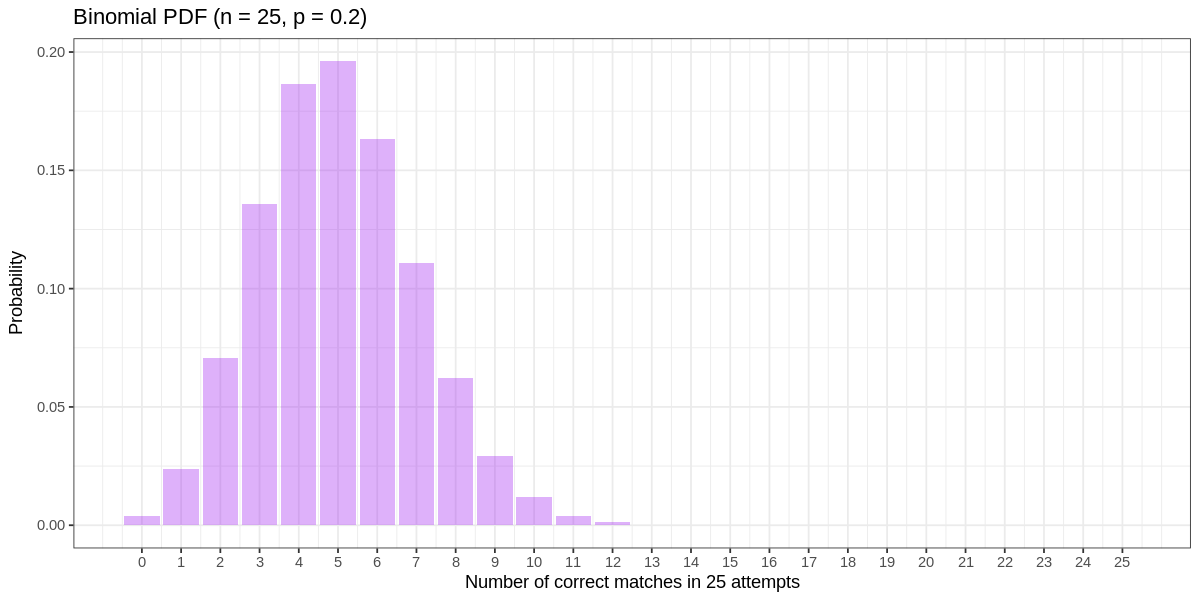

In [ ]:
n = 25   # I had 25 attempts
p = 0.2  # it is convention to assume p is the value in the null hypothesis, H0

# theoretical probability of each possible value of X
true_df = data.frame(
  successes = 0:n,
  true_prob = dbinom(0:n, size = n, prob = p)
)

# controls the width and height of the plot
options(repr.plot.width = 10, repr.plot.height =5)

# plot code for bar plot with labels
ggplot() +
  # true probabilities as bars
  geom_col(
    data = true_df,
    aes(x = successes, y = true_prob),
    fill = "purple",
    alpha = 0.35
  ) +
  # set the x-axis tickmarks and labels
  scale_x_continuous(
    breaks = 0:n,                  # Tick positions
    labels = 0:n # Labels for each tick
  ) +
  labs(
    title = "Binomial PDF (n = 25, p = 0.2)",
    x = "Number of correct matches in 25 attempts",
    y = "Probability"
  ) +
  theme_bw()


**Step 2**: Collect data $x$ from $n=25$ attempts and visualize it in a pie chart.  I got 4 correct matches in 25 attempts so my $x=4$.

In [ ]:
# use R to change from count to proportion correct

x = 4
n = 25

phat = x/n
phat

[1] 0.16

In [ ]:
# rather than loading my very small dataset (4 and 25-4=21) from a spreadsheet, I'll just
# manually type the numbers into R via a data.frame:

mydata = data.frame(
  Attempts = c("Correct", "Incorrect"),
  Count = c(x, n-x)
)

mydata

Attempts,Count
<chr>,<dbl>
Correct,4
Incorrect,21


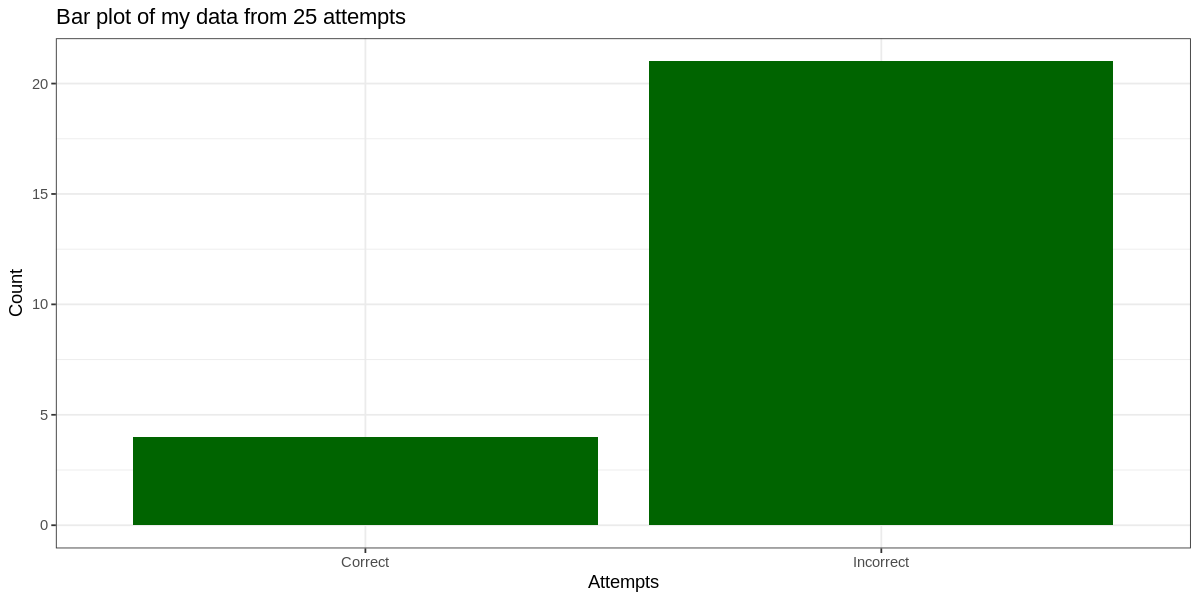

In [ ]:
ggplot(mydata, aes(x=Attempts, y=Count))+
  geom_col(fill="darkgreen")+
  labs(
    title = "Bar plot of my data from 25 attempts"
  ) +
  theme_bw()

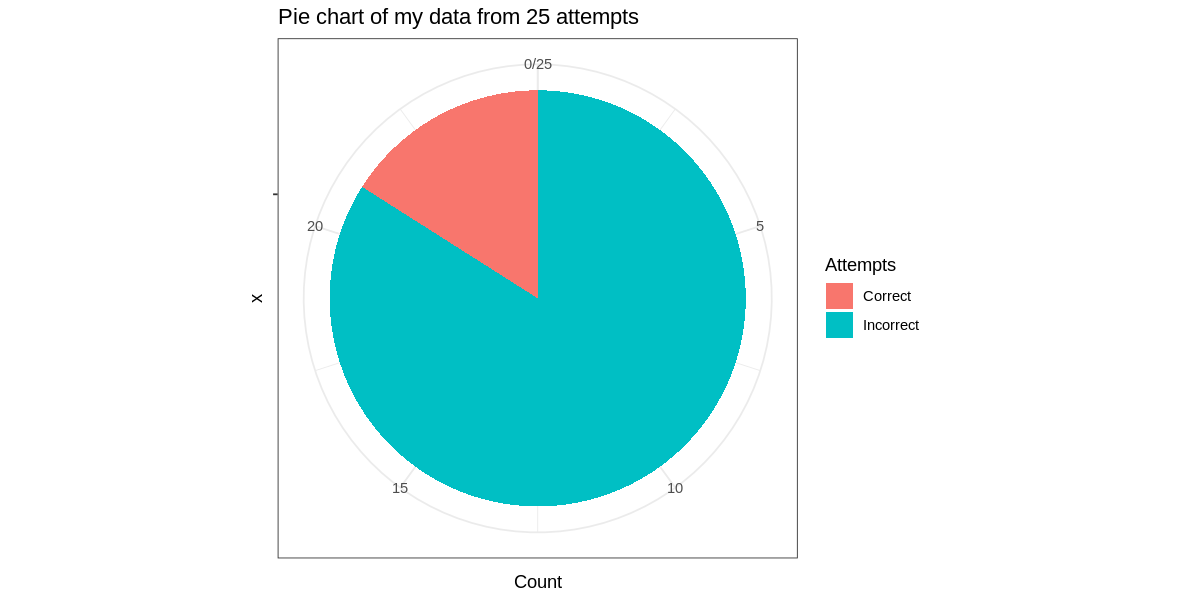

In [ ]:
ggplot(mydata, aes(x="", fill=Attempts, y=Count))+
  geom_col()+
  coord_polar(theta = "y") +
  labs(
    title = "Pie chart of my data from 25 attempts",
  ) +
  theme_bw()

**Step 3** Add the observed count of successes to the Binomial Distribution plot as a vertical line. Notice I just copied the code from Step 1 and added a new line, `geom_vline`.

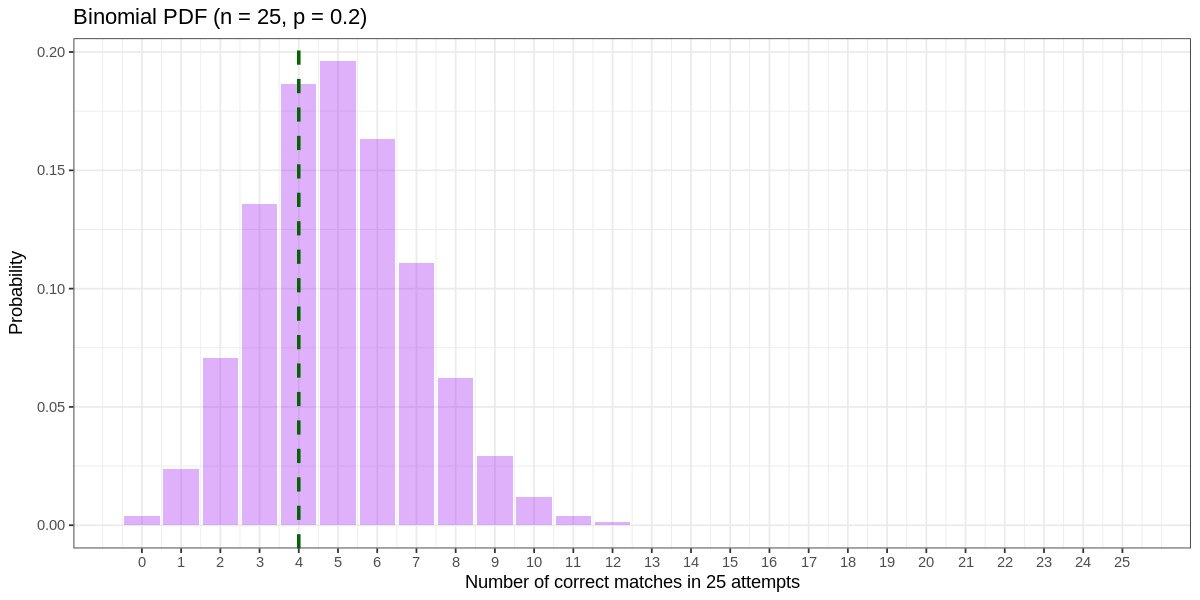

In [ ]:
n = 25   # I had 25 attempts
p = 0.2  # it is convention to assume p is the value in the null hypothesis, H0
x = 4 # I got 4 correct matches in 25 attempts

# theoretical probability of each possible value of X
true_df = data.frame(
  successes = 0:n,
  true_prob = dbinom(0:n, size = n, prob = p)
)

# controls the width and height of the plot
options(repr.plot.width = 10, repr.plot.height =5)

# plot code for bar plot with labels
ggplot() +
  # true probabilities as bars
  geom_col(
    data = true_df,
    aes(x = successes, y = true_prob),
    fill = "purple",
    alpha = 0.35
  ) +
  # set the x-axis tickmarks and labels
  scale_x_continuous(
    breaks = 0:n,                  # Tick positions
    labels = 0:n # Labels for each tick
  ) +
  geom_vline(xintercept = x, linetype = "dashed", linewidth = 1, color="darkgreen")+
  labs(
    title = "Binomial PDF (n = 25, p = 0.2)",
    x = "Number of correct matches in 25 attempts",
    y = "Probability"
  ) +
  theme_bw()



Notice that my data at the green line $x=4$ is fairly likely to occur (that is, the purple bars near my data are relatively high) if I don't have ESP.  In other words, my data is consistent with $H_0: p=0.2$.  So I can't reject the hypothesis that I don't have ESP based on my data from this study.

**Step 4**: Compute a p-value using the Binomial Distribution with the values of $n$ and $p$ from $H_0$, your observed data value $x$ and the direction of the inequality in $H_a$

Since my alterative hypothesis was $H_0: p>0.2$, that I have a better than expected chance of getting a correct match than if I were guessing, the direction in my p-value is ">".  Since my observed value of $x$ was 4, my p-value is $P(X\geq 4)$ and should be computed using the Binomial Distribution with $n=25$ and $p=0.2$.


In [ ]:
# option 1: sum all P(X=x) from the observed value of x to either 0 or n depending on the direction
n=25
p=0.2
x=4

# this should match the sum you'd get if you added up all the heights of the purple bars from the data line to the right (or left if your direction is <)
pvalue = sum(dbinom(x:n, size=n, prob=p))
pvalue

[1] 0.7660067

In [ ]:
# option 2: use pbinom with x and lower.tail = TRUE if < or with x-1 and lower.tail = FALSE if >

In [ ]:
pvalue = pbinom(q=x-1, size=n, prob=p, lower.tail = FALSE)
pvalue

[1] 0.7660067

**Step 5** Carefully write a one sentence description of the meaning the p-value calculation, which combines your data and the two hypotheses.

The interpretation of p-value should involve the direction and values of n, p and x:  "assuming that I'm just guessing in 25 attempts (p=0.2 is guessing), the probability of getting 4 or more correct matches is 0.766".

**Step 6**: Add the size of the p-value to the plot from step 3 and double check that you have interpreted it correctly and the area matches the number you got in step 4.

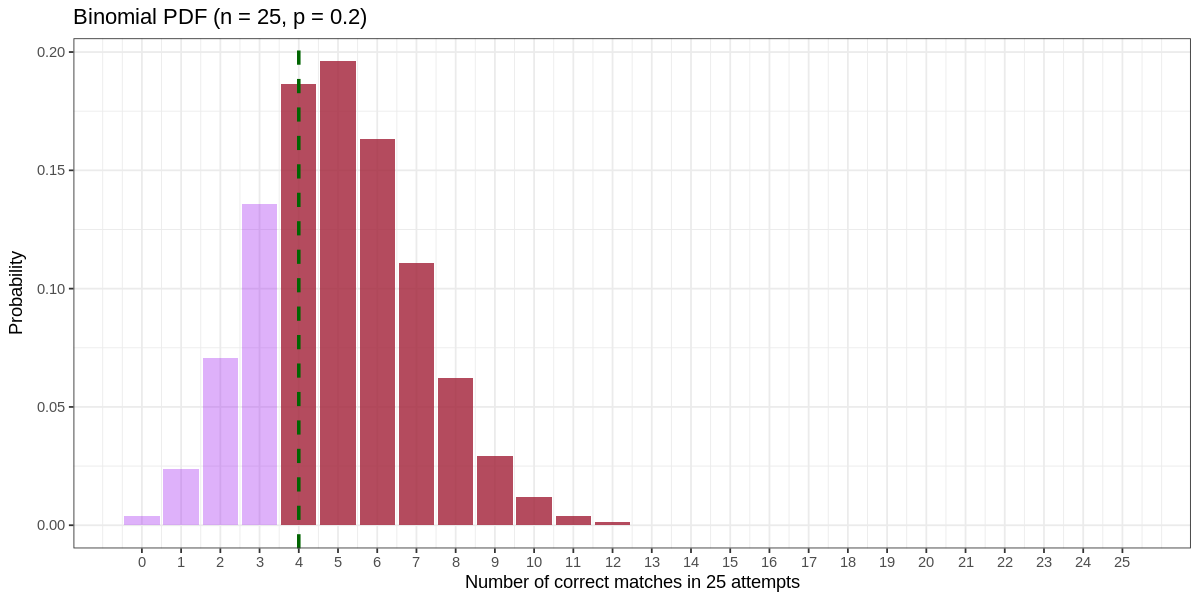

In [ ]:
n = 25   # I had 25 attempts
p = 0.2  # it is convention to assume p is the value in the null hypothesis, H0
x = 4    # I got 4 correct matches in 25 attempts

# theoretical probability of each possible value of X
true_df = data.frame(
  successes = 0:n,
  true_prob = dbinom(0:n, size = n, prob = p)
)

# controls the width and height of the plot
options(repr.plot.width = 10, repr.plot.height =5)

# plot code for bar plot with labels
ggplot() +
  # true probabilities as bars
  geom_col(
    data = true_df,
    aes(x = successes, y = true_prob),
    fill = "purple",
    alpha = 0.35
  ) +
  # Make the area corresponding to the p-value dark brown
  geom_col(
    data = subset(true_df, successes >= x),
    aes(x = successes, y = true_prob),
    fill = "brown",
    alpha = 0.75
  ) +
  # set the x-axis tickmarks and labels
  scale_x_continuous(
    breaks = 0:n,                  # Tick positions
    labels = 0:n # Labels for each tick
  ) +
  geom_vline(xintercept = x, linetype = "dashed", linewidth = 1, color="darkgreen")+
  labs(
    title = "Binomial PDF (n = 25, p = 0.2)",
    x = "Number of correct matches in 25 attempts",
    y = "Probability"
  ) +
  theme_bw()



Notice that the brown area corresponding to my p-value is large, covering up most of the purple.  This shows that my data (or more extreme) is likely if the purple distribution is correct.  Since the purple distribution was generated assuming I'm just guessing (p=0.2), this means my data is consistent with guessing.  In short, a large p-value means data is consistent with $H_0$.  If the area/p-value were small, then I'd reject $H_0$ because my data was not consistent with it.